# India COVID-19 EDA — Code Notebook
Run each cell top to bottom in Google Colab.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)

## 2. Load data

In [2]:
cases = pd.read_csv(
    "https://raw.githubusercontent.com/imdevskp/covid-19-india-data/master/complete.csv"
)
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/vaccinations/country_data/India.csv"
)

print("Cases shape:", cases.shape)
print("Vaccination shape:", vax.shape)
cases.head()

Cases shape: (4692, 10)
Vaccination shape: (1250, 8)


,Date,Name of State / UT,Latitude,Longitude,Total Confirmed cases,Death,Cured/Discharged/Migrated,New cases,New deaths,New recovered
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0


## 3. Inspect

In [3]:
cases.dtypes

,0
Date,object
Name of State / UT,object
Latitude,float64
Longitude,float64
Total Confirmed cases,float64
Death,object
Cured/Discharged/Migrated,float64
New cases,int64
New deaths,int64
New recovered,int64


In [4]:
cases.isna().sum()

,0
Date,0
Name of State / UT,0
Latitude,0
Longitude,0
Total Confirmed cases,0
Death,0
Cured/Discharged/Migrated,0
New cases,0
New deaths,0
New recovered,0


In [5]:
print("Unique state/UT names:", cases["Name of State / UT"].nunique())
sorted(cases["Name of State / UT"].unique())

Unique state/UT names: 40


['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Telangana***',
 'Telengana',
 'Tripura',
 'Union Territory of Chandigarh',
 'Union Territory of Jammu and Kashmir',
 'Union Territory of Ladakh',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

## 4. Clean

In [6]:
cases.columns = [
    "date", "state", "lat", "long", "confirmed",
    "deaths", "cured", "new_cases", "new_deaths", "new_recovered",
]

cases["date"] = pd.to_datetime(cases["date"])
cases["deaths"] = pd.to_numeric(cases["deaths"], errors="coerce").fillna(0).astype(int)

name_fix = {
    "Telangana***": "Telangana",
    "Telengana": "Telangana",
    "Union Territory of Jammu and Kashmir": "Jammu and Kashmir",
    "Union Territory of Ladakh": "Ladakh",
    "Union Territory of Chandigarh": "Chandigarh",
}
cases["state"] = cases["state"].replace(name_fix)

cases = cases.drop_duplicates(subset=["date", "state"])
cases["active"] = cases["confirmed"] - cases["deaths"] - cases["cured"]

print("Clean state count:", cases["state"].nunique())
cases.head()

Clean state count: 35


,date,state,lat,long,confirmed,deaths,cured,new_cases,new_deaths,new_recovered,active
0,2020-01-30,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0,1.0
1,2020-01-31,Kerala,10.8505,76.2711,1.0,0,0.0,0,0,0,1.0
2,2020-02-01,Kerala,10.8505,76.2711,2.0,0,0.0,1,0,0,2.0
3,2020-02-02,Kerala,10.8505,76.2711,3.0,0,0.0,1,0,0,3.0
4,2020-02-03,Kerala,10.8505,76.2711,3.0,0,0.0,0,0,0,3.0


## 5. Feature engineering & aggregation

In [7]:
cases["recovery_rate"] = (cases["cured"] / cases["confirmed"] * 100).round(2)
cases["death_rate"] = (cases["deaths"] / cases["confirmed"] * 100).round(2)
cases["month"] = cases["date"].dt.strftime("%Y-%m")

national = cases.groupby("date", as_index=False)[["confirmed", "deaths", "cured"]].sum()
national["recovery_rate"] = (national["cured"] / national["confirmed"] * 100).round(2)
national["death_rate"] = (national["deaths"] / national["confirmed"] * 100).round(2)
national["new_confirmed"] = national["confirmed"].diff().fillna(national["confirmed"])

latest_date = cases["date"].max()
latest = cases[cases["date"] == latest_date].sort_values("confirmed", ascending=False)

by_state = latest.groupby("state", as_index=False)[["confirmed", "deaths", "cured",
                                                      "recovery_rate", "death_rate"]].sum()
by_state = by_state.sort_values("confirmed", ascending=False)

pivot = cases.pivot_table(values="new_cases", index="state", columns="month",
                           aggfunc="sum", fill_value=0)

print("Latest date:", latest_date.date())
national.tail()

Latest date: 2020-08-06


,date,confirmed,deaths,cured,recovery_rate,death_rate,new_confirmed
181,2020-08-02,1750723.0,37364,1145629.0,65.44,2.13,54735.0
182,2020-08-03,1803695.0,38135,1186203.0,65.77,2.11,52972.0
183,2020-08-04,1855745.0,38938,1230509.0,66.31,2.10,52050.0
184,2020-08-05,1908254.0,39795,1282215.0,67.19,2.09,52509.0
185,2020-08-06,1964536.0,40699,1328336.0,67.62,2.07,56282.0


## 6. Visualisations

### 6.1 Cumulative national trend

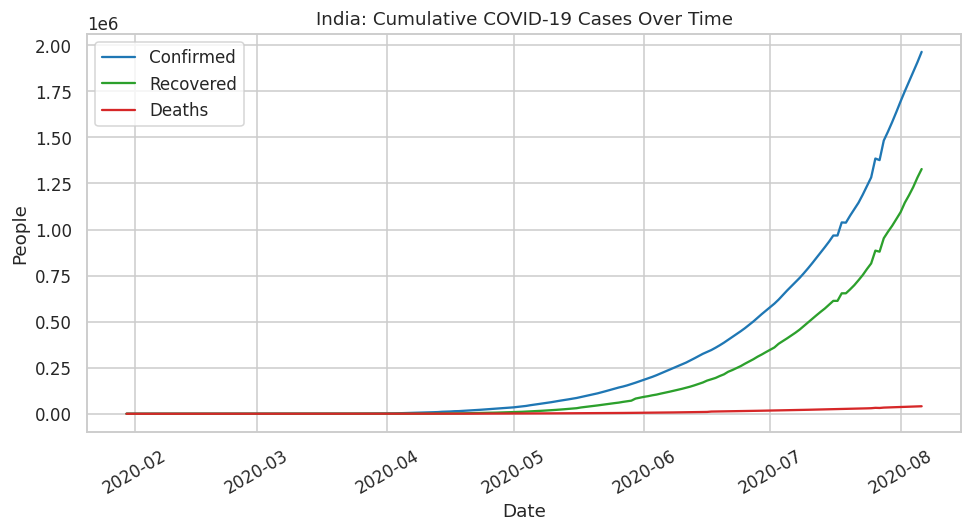

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(national["date"], national["confirmed"], label="Confirmed", color="tab:blue")
ax.plot(national["date"], national["cured"], label="Recovered", color="tab:green")
ax.plot(national["date"], national["deaths"], label="Deaths", color="tab:red")
ax.set_title("India: Cumulative COVID-19 Cases Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("People")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.2 Daily new confirmed cases

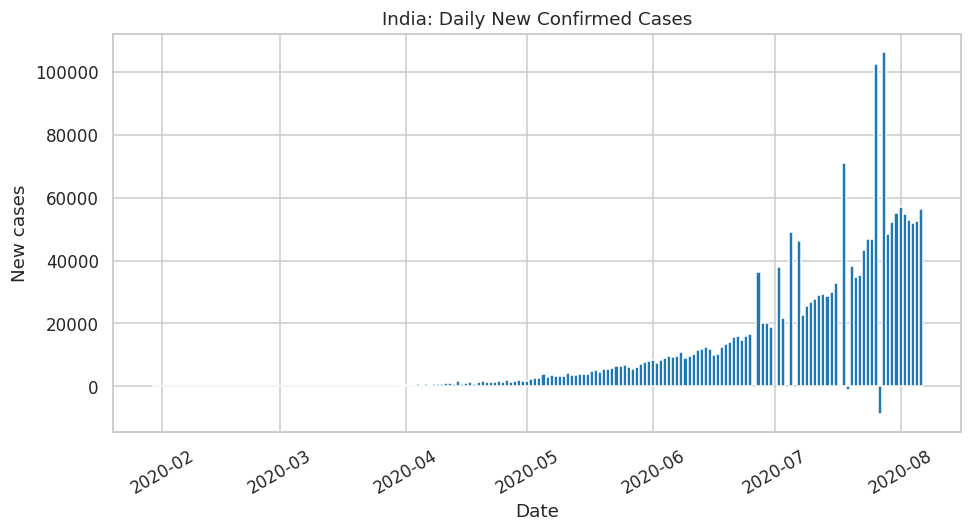

Peak new cases in a day: 106,421 on 2020-07-28


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(national["date"], national["new_confirmed"], color="tab:blue", width=1.0)
ax.set_title("India: Daily New Confirmed Cases")
ax.set_xlabel("Date"); ax.set_ylabel("New cases")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Peak new cases in a day: {int(national['new_confirmed'].max()):,} "
      f"on {national.loc[national['new_confirmed'].idxmax(), 'date'].date()}")

### 6.3 Top 10 states by confirmed cases

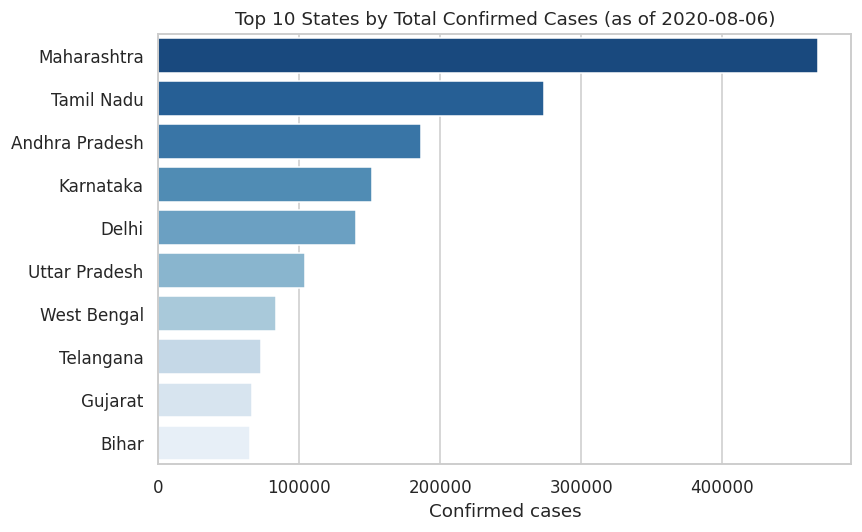

In [10]:
top10 = by_state.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="state", x="confirmed", hue="state", palette="Blues_r",
            legend=False, ax=ax)
ax.set_title(f"Top 10 States by Total Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 6.4 Share of national cases (top 6 states + rest)

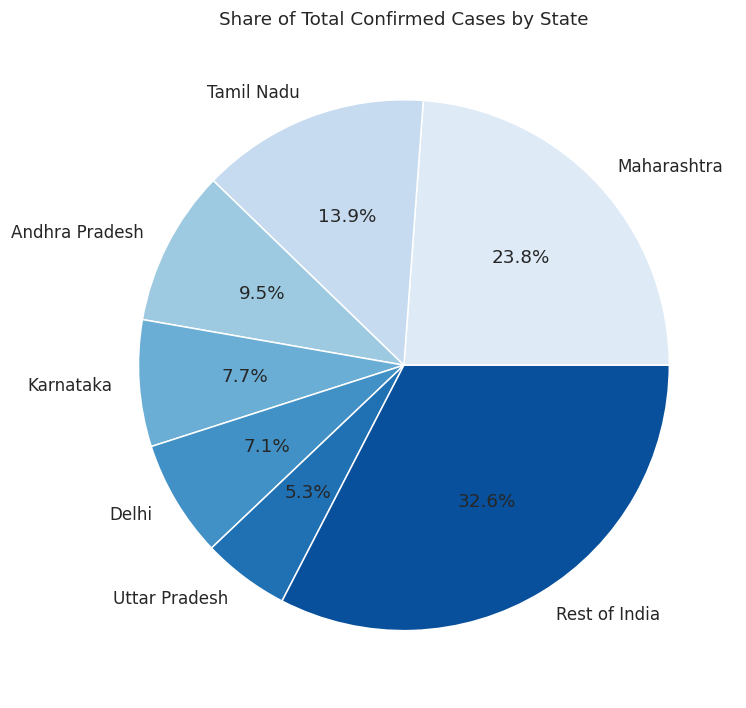

In [11]:
top6 = by_state.head(6).copy()
rest = by_state["confirmed"][6:].sum()
pie_data = pd.concat([top6[["state", "confirmed"]],
                       pd.DataFrame({"state": ["Rest of India"], "confirmed": [rest]})],
                      ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(pie_data["confirmed"], labels=pie_data["state"], autopct="%1.1f%%",
       colors=sns.color_palette("Blues", len(pie_data)))
ax.set_title("Share of Total Confirmed Cases by State")
plt.tight_layout()
plt.show()

### 6.5 Confirmed-case growth — top 5 states over time

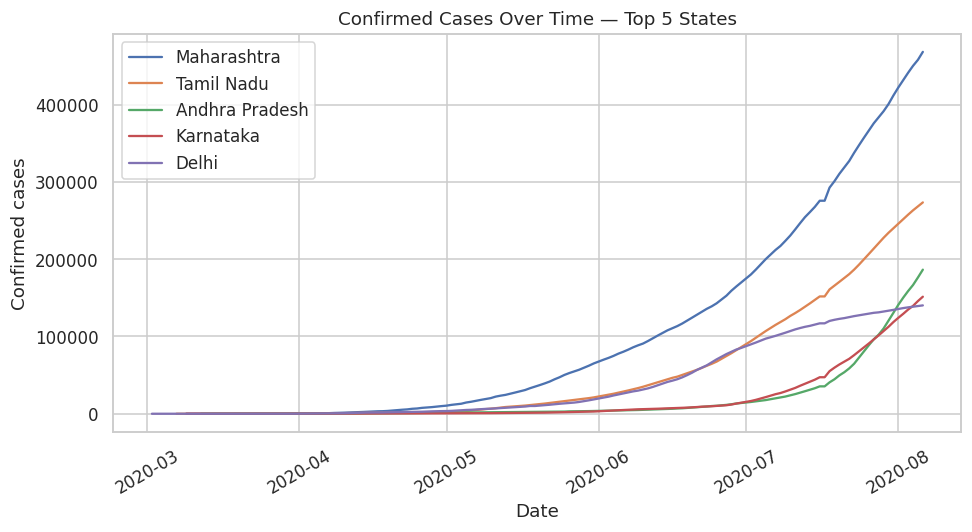

In [12]:
top5_states = by_state.head(5)["state"].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
for state in top5_states:
    sd = cases[cases["state"] == state]
    ax.plot(sd["date"], sd["confirmed"], label=state)
ax.set_title("Confirmed Cases Over Time — Top 5 States")
ax.set_xlabel("Date"); ax.set_ylabel("Confirmed cases")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.6 Recovery rate — top 10 worst-hit states

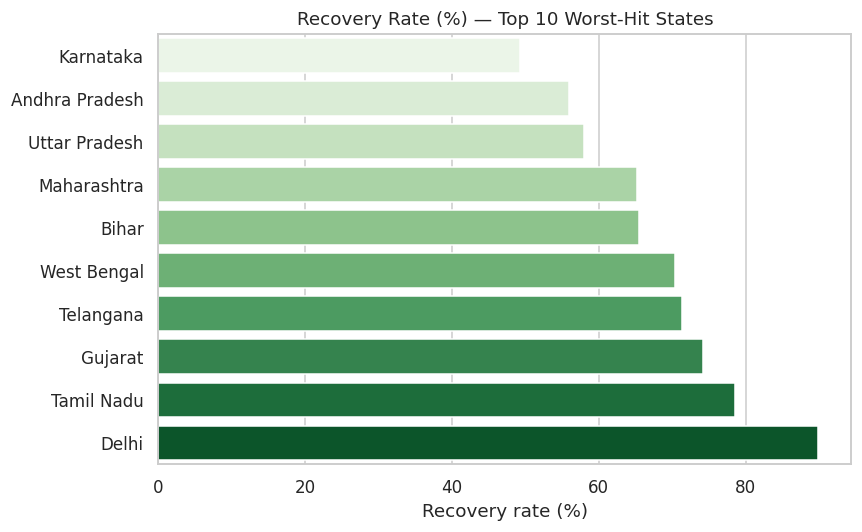

In [13]:
rec10 = by_state.head(10).sort_values("recovery_rate")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=rec10, y="state", x="recovery_rate", hue="state", palette="Greens",
            legend=False, ax=ax)
ax.set_title("Recovery Rate (%) — Top 10 Worst-Hit States")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 6.7 National recovery rate over time

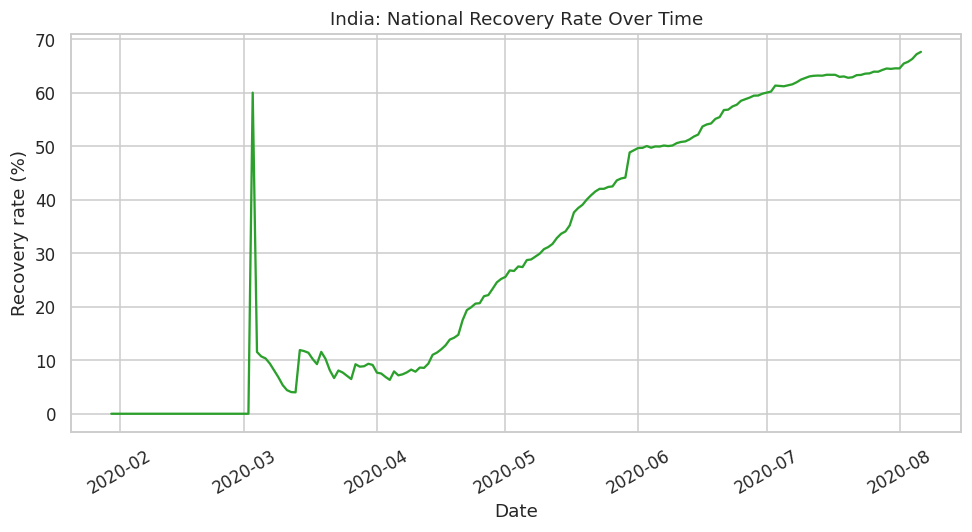

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(national["date"], national["recovery_rate"], color="tab:green")
ax.set_title("India: National Recovery Rate Over Time")
ax.set_xlabel("Date"); ax.set_ylabel("Recovery rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.8 Recovery rate vs death rate (bubble = case count)

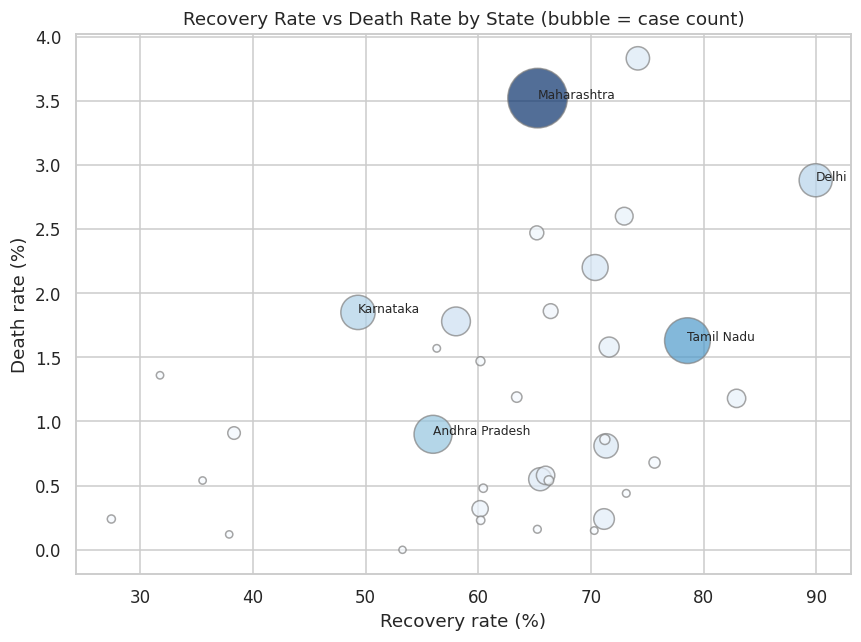

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sizes = (latest["confirmed"] / latest["confirmed"].max()) * 1500 + 20
ax.scatter(latest["recovery_rate"], latest["death_rate"], s=sizes,
           c=latest["confirmed"], cmap="Blues", alpha=0.7, edgecolor="grey")

for _, row in latest[latest["state"].isin(top5_states)].iterrows():
    ax.annotate(row["state"], (row["recovery_rate"], row["death_rate"]), fontsize=8)

ax.set_title("Recovery Rate vs Death Rate by State (bubble = case count)")
ax.set_xlabel("Recovery rate (%)"); ax.set_ylabel("Death rate (%)")
plt.tight_layout()
plt.show()

### 6.9 Correlation between national metrics

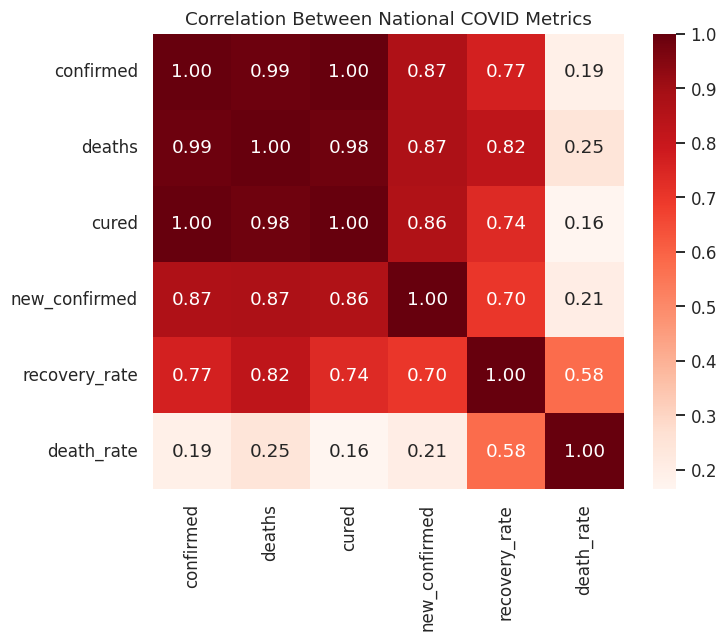

In [16]:
corr_cols = ["confirmed", "deaths", "cured", "new_confirmed", "recovery_rate", "death_rate"]
corr = national[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Reds", ax=ax)
ax.set_title("Correlation Between National COVID Metrics")
plt.tight_layout()
plt.show()

### 6.10 Spread of daily new cases by month

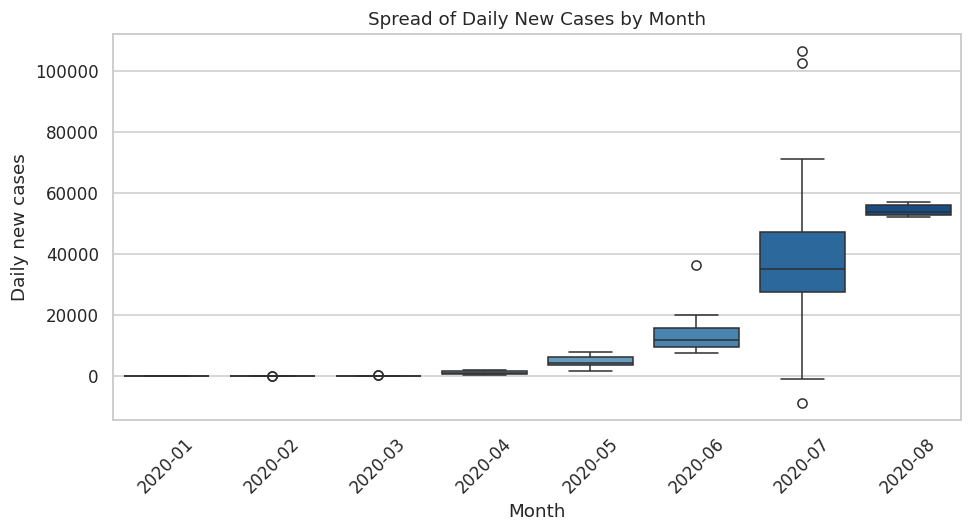

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=national.assign(month=national["date"].dt.strftime("%Y-%m")),
            x="month", y="new_confirmed", hue="month", palette="Blues", legend=False, ax=ax)
ax.set_title("Spread of Daily New Cases by Month")
ax.set_xlabel("Month"); ax.set_ylabel("Daily new cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.11 Least-affected states/UTs

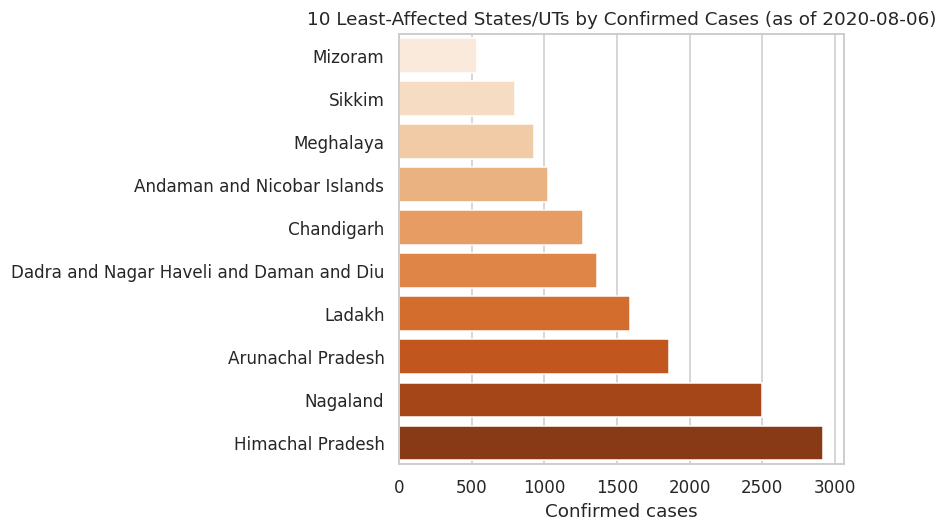

In [18]:
bottom10 = latest[latest["confirmed"] > 0].nsmallest(10, "confirmed")

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=bottom10, y="state", x="confirmed", hue="state", palette="Oranges",
            legend=False, ax=ax)
ax.set_title(f"10 Least-Affected States/UTs by Confirmed Cases (as of {latest_date.date()})")
ax.set_xlabel("Confirmed cases"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 6.12 National vaccination progress (OWID)

Shape: (1250, 8)
Columns: ['location', 'date', 'vaccine', 'source_url', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters']
Using dose column: total_vaccinations
Using fully-vaccinated column: people_fully_vaccinated

Rows available for plotting: 1250
Date range: 2021-01-15 to 2024-08-12


ValueError: 'tab:teal' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

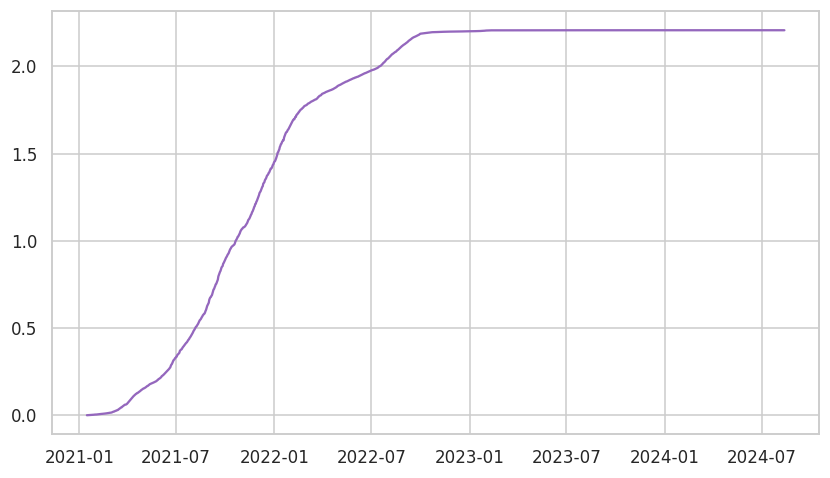

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Load fresh ---
vax = pd.read_csv(
    "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/"
    "vaccinations/country_data/India.csv"
)

print("Shape:", vax.shape)
print("Columns:", vax.columns.tolist())

# --- 2) Parse the date column ---
vax["date"] = pd.to_datetime(vax["date"], errors="coerce")

# --- 3) Auto-detect the right column names instead of hard-coding them ---
def find_col(df, must_have, prefer=None):
    candidates = [c for c in df.columns if all(k.lower() in c.lower() for k in must_have)]
    if prefer and prefer in candidates:
        return prefer
    return candidates[0] if candidates else None

dose_col = find_col(vax, ["total", "vaccinat"], prefer="total_vaccinations")
fully_col = find_col(vax, ["fully", "vaccinat"], prefer="people_fully_vaccinated")

print("Using dose column:", dose_col)
print("Using fully-vaccinated column:", fully_col)

if dose_col is None or fully_col is None:
    raise ValueError(
        f"Could not find the expected columns. Available columns are: {vax.columns.tolist()}"
    )

# --- 4) Force both to numeric, turning anything unparseable into NaN ---
vax[dose_col] = pd.to_numeric(vax[dose_col], errors="coerce")
vax[fully_col] = pd.to_numeric(vax[fully_col], errors="coerce")

# --- 5) Keep only rows where at least one of the two metrics has a value ---
vax_plot = vax.dropna(subset=[dose_col, fully_col], how="all").sort_values("date")

if vax_plot.empty:
    raise ValueError("No usable vaccination data found after cleaning — check the printed "
                      "columns/sample rows above to see what's actually in this file.")

print("\nRows available for plotting:", vax_plot.shape[0])
print("Date range:", vax_plot["date"].min().date(), "to", vax_plot["date"].max().date())

# --- 6) Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(vax_plot["date"], vax_plot[dose_col] / 1e9, label="Total doses (Bn)", color="tab:purple")
ax.plot(vax_plot["date"], vax_plot[fully_col] / 1e9, label="Fully vaccinated (Bn)", color="tab:teal")
ax.set_title("India: COVID-19 Vaccination Progress")
ax.set_xlabel("Date")
ax.set_ylabel("People / doses (in billions)")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



## 7. Save cleaned data

In [20]:
cases.to_csv("cleaned_covid_india.csv", index=False)
print("Saved cleaned_covid_india.csv —", cases.shape[0], "rows.")

Saved cleaned_covid_india.csv — 4692 rows.
